## Assignment 2 - Clustering

## Learning Outcomes

In this assignment, you will do the following:

* Explore a dataset and carry out clustering using k-means algorithm

* Identify the optimum number of clusters for a given dataset



## Problem Description

In this assignment, you will study the electricity demand from clients in Portugal, during 2013 and 2014. You have been provided with the data file, which you should download when you download this assignment file.

The data$^1$ available contains 370 time series, corresponding to the electric demand$^2$ for 370 clients, between 2011 and 2014. 

In this guided exercise, you will use clustering techniques to understand the typical usage behaviour during 2013-2014.

Both these datasets are publicly available, and can be used to carry out experiments. Their source is below:

 1. Data:
https://archive.ics.uci.edu/ml/datasets/ElectricityLoadDiagrams20112014#

 2. Electric Demand:
http://www.think-energy.net/KWvsKWH.htm

We will start by exploring the data set and continue on to the assignment.  Consider this as a working notebook, you will add your work to the same notebook.

In this assignment we will use the sklearn package for k-means.  Please refer here for the documentation https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html
(https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html).

The sklearn package for k-means is one of the many clustering algorithms found in the module "sklearn.cluster".  These come with a variety of functions that you can call by importing the package.

For example 
    
    from sklearn.cluster import AgglomerativeClustering
    from sklearn.cluster import KMeans



## Data Preparation

Start by downloading the data to a local directory and modify the "pathToFile" and "fileName" variables, if needed. The data file has been provided with this assignment. It is also available at the links provided above.

In [1]:
pathToFile = r"C:\\Users\\camer\\Downloads\\"
#pathToFile = r"C:\\Users\\<your username>\\Downloads\\"
fileName = 'LD2011_2014.txt'

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import random
from sklearn import metrics
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering

random.seed(42)

In [3]:
# Replace "," by ".", otherwise the numbers will be in the form 2,3445 instead of 2.3445
import fileinput

with fileinput.FileInput(pathToFile+fileName, inplace=True, backup='.bak') as file:
    for line in file:
        print(line.replace(",", "."), end='')

In [4]:
# Create dataframe
import pandas as pd
data = pd.read_csv(pathToFile+fileName, sep=";", index_col=0)

### Quick data inspection

In [5]:
data.head(2)

,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
2011-01-01 00:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 00:30:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
data.tail(2)

,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
2014-12-31 23:45:00,1.269036,21.337127,1.737619,166.666667,85.365854,285.714286,10.17524,225.589226,64.685315,72.043011,...,246.252677,28000.0,1443.037975,909.090909,26.075619,4.095963,664.618086,146.911519,646.627566,6540.540541
2015-01-01 00:00:00,2.538071,19.914651,1.737619,178.861789,84.146341,279.761905,10.17524,249.158249,62.937063,69.892473,...,188.436831,27800.0,1409.282700,954.545455,27.379400,4.095963,628.621598,131.886477,673.020528,7135.135135


In [7]:
data.shape

(140256, 370)

#### As it can be seen, the dataframe contains a row for each interval of 15 minutes between Jan 1, 2011 to Dec 31 2014. There are 370 columns corresponding 370 clients. The dataframe is indexed by the timestamp.

Since the frequency is 15 minutes, each day provides $24\times 4 = 96$ datapoints, which multiplied by 365 days and 4 years (plus 1 day in Feb 29, 2012) gives: $96 \times 365 \times 4 + 96 = 140256$, as observed in data.shape

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 140256 entries, 2011-01-01 00:15:00 to 2015-01-01 00:00:00
Columns: 370 entries, MT_001 to MT_370
dtypes: float64(370)
memory usage: 397.0+ MB


In [9]:
data.describe()

,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
count,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,...,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000
mean,3.970785,20.768480,2.918308,82.184490,37.240309,141.227385,4.521338,191.401476,39.975354,42.205152,...,218.213701,37607.987537,1887.427366,2940.031734,65.413150,9.269709,424.262904,94.704717,625.251734,8722.355145
std,5.983965,13.272415,11.014456,58.248392,26.461327,98.439984,6.485684,121.981187,29.814595,33.401251,...,204.833532,38691.954832,1801.486488,2732.251967,65.007818,10.016782,274.337122,80.297301,380.656042,9195.155777
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.844950,0.000000,36.585366,15.853659,71.428571,0.565291,111.111111,13.986014,9.677419,...,5.710207,0.000000,0.000000,0.000000,13.037810,0.000000,0.000000,30.050083,83.944282,0.000000
50%,1.269036,24.893314,1.737619,87.398374,39.024390,157.738095,2.826456,222.222222,40.209790,40.860215,...,131.334761,24100.000000,1050.632911,2136.363636,31.290743,7.021650,525.899912,76.794658,758.064516,0.000000
75%,2.538071,29.871977,1.737619,115.853659,54.878049,205.357143,4.522329,279.461279,57.692308,61.290323,...,403.283369,54800.000000,3312.236287,5363.636364,108.213820,11.702750,627.743635,151.919866,875.366569,17783.783784
max,48.223350,115.220484,151.172893,321.138211,150.000000,535.714286,44.657999,552.188552,157.342657,198.924731,...,852.962170,192800.000000,7751.054852,12386.363636,335.071708,60.269163,1138.718174,362.270451,1549.120235,30918.918919


### Plot the first 2 days of 2012 for the first 2 clients

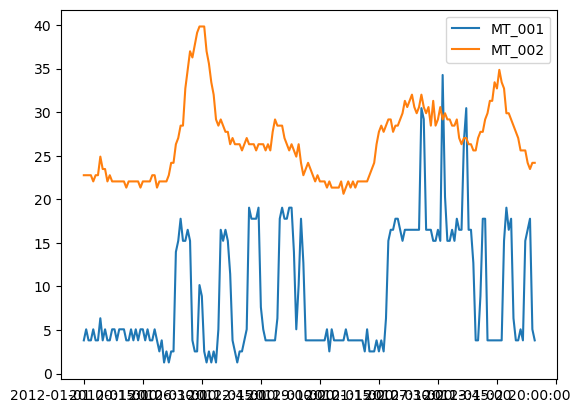

In [10]:
data_example = data.loc['2012-01-01 00:15:00':'2012-01-03 00:00:00'][['MT_001','MT_002']]
data_example.plot()
plt.show()

#### We  note that the main difference between the curves is the level (also seen on the means in df.describe()).  We know we will have to somehow normalize the curves, in order for the clustering technique to capture the behaviour of the consumption throughout the day.

### Data for the analysis

We focus on 2013 and 2014 because these are the years with low number of clients having zero demand

In [11]:
data2011 = data.loc['2011-01-01 00:15:00':'2012-01-01 00:00:00']
data2012 = data.loc['2012-01-01 00:15:00':'2013-01-01 00:00:00']
data2013 = data.loc['2013-01-01 00:15:00':'2014-01-01 00:00:00']
data2014 = data.loc['2014-01-01 00:15:00':'2015-01-01 00:00:00']

In [12]:
# Check number of days
print(data2011.shape[0]/96)
print(data2012.shape[0]/96)
print(data2013.shape[0]/96)
print(data2014.shape[0]/96)

365.0
366.0
365.0
365.0


In [13]:
# See number of clients with 0 demand per year
print(sum(data2011.mean()==0))
print(sum(data2012.mean()==0))
print(sum(data2013.mean()==0))
print(sum(data2014.mean()==0))

210
37
21
1


In [14]:
clients = data2011.columns
clients_no_demand = clients[data2013.mean()==0] # clients with 0 demand
data_13_14 = data2013.append(data2014) # appending 2013 and 2014
data_13_14 = data_13_14.drop(clients_no_demand, axis=1) # drop clients with 0 demand
print(data_13_14.shape)
print(sum(data_13_14.mean()==0)) # check that there are no clients with 0 demand

(70080, 349)
0


C:\Users\camer\AppData\Local\Temp\ipykernel_12964\2042128106.py:3: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  data_13_14 = data2013.append(data2014) # appending 2013 and 2014


## Getting average curves per client

In [15]:
data = data_13_14.copy() # weekdays weekends, data2011, data2012, data2013, data2014

In [16]:
data['hour'] = data.index.map(lambda x: x[11:])

In [17]:
data.head(3)

,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370,hour
2013-01-01 00:15:00,2.538071,22.759602,2.606429,138.211382,63.414634,255.952381,4.522329,239.057239,57.692308,78.494624,...,22300.0,886.075949,1000.000000,16.949153,6.436513,616.330114,76.794658,731.671554,8086.486486,00:15:00
2013-01-01 00:30:00,1.269036,22.759602,2.606429,138.211382,63.414634,264.880952,5.652911,228.956229,57.692308,76.344086,...,21000.0,864.978903,909.090909,18.252934,3.510825,564.530290,76.794658,727.272727,8086.486486,00:30:00
2013-01-01 00:45:00,2.538071,22.759602,2.606429,134.146341,60.975610,250.000000,5.652911,239.057239,54.195804,76.344086,...,18200.0,860.759494,840.909091,16.949153,5.851375,590.869183,68.447412,730.205279,7848.648649,00:45:00


### Getting average curves per client

In [18]:
datagrouped = data.groupby("hour")
average_curves = datagrouped.agg("mean")
average_curves.shape 

(96, 349)

#### The dataframe average_curves contains the 349 typical weekday electric demands

#### We now divide each curve by its mean, so that all curves have mean 1

In [19]:
average_curves_norm = average_curves/(average_curves.mean())

#### Plot the first 2 and last 2 clients

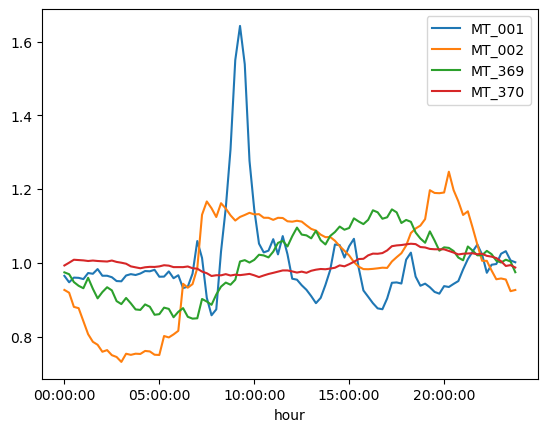

In [20]:
average_curves_norm[['MT_001','MT_002','MT_369','MT_370']].plot()
plt.show()

In [21]:
average_curves_norm[['MT_001']]

,MT_001
hour,
00:00:00,0.964792
00:15:00,0.947378
00:30:00,0.960104
00:45:00,0.959434
01:00:00,0.956085
...,...
22:45:00,0.996941
23:00:00,1.024736
23:15:00,1.031768


## Clustering Analysis on the average normalized curves

In [22]:
X = average_curves_norm.copy()  # We call this normalized curve
X = np.array(X.T) # put it on the right format - Transpose it

In [23]:
X.shape

(349, 96)

# Questions (15 marks total)

**Q1: (7 marks)**

a. Determine what a convenient number of clusters. Justify your choice.  Make use of the sklearn's package for k-means for this. You may refer to the module to figure out how to come up with the optimal number of clusters. 

b. Make a plot for each cluster, that includes:
    - The number of clients in the cluster (you can put this in the title of the plot)
    - All the curves in the cluster
    - The curve corresponding to the center of the cluster (make this curve thicker to distinguish it from the individual curves).  The center is also sometimes referred to as "centroid".
    
You have 2 separate plots for each cluster if you prefer (one for the individual curves, one for the centroid)

In [24]:
# Define some generic functions.

In [25]:
# invoke_kmeans

def invoke_kmeans(X_in, num_clusters, num_runs=10, num_iterations=300):

    # For deterministic k-means clustering, set the random_num
    random_num = 0        

    # Invoke the KMeans function and fit the X data.
    kmeans = KMeans(init="random", n_clusters=num_clusters, n_init=num_runs, max_iter=num_iterations,
                    random_state=random_num)
    kmeans.fit(X_in)

    # Return the object.
    return kmeans


# print_kmeans_data

def print_kmeans_data(kmeans):
    print ("Inertia: ", kmeans.inertia_)
    print ("n_iter:  ", kmeans.n_iter_)

In [26]:
# create_x_and_y_parallel_array
def create_x_and_y_parallel_array(data_in):

    # Create blank parallel arrays
    x_data = []
    y_data = []

    # Iterate over the 2d array ([x, y]) and add the x and y values
    # to their respective parallel arrays.
    for j in data_in:
        x_data.append(j[0])
        y_data.append(j[1])
    
    return x_data, y_data


In [27]:
# plot_line_graph
def plot_line_graph(x_data, y_data, title="No Title", x_label="No X", y_label="No Y"):

    # Create the figure. 
    plt.figure(dpi=100)

    # Set line graph details.
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)

    # Create arrays from the x_data and y_data lists.
    x = np.array(x_data)
    y = np.array(y_data)

    # Plot the arrays.
    plt.plot(x,y)

    # Display the plot.
    plt.show()

Find the optimal number of clusters.

In [28]:
my_data = []

# Invoke kmeans clustering starting from 2 clusters to 200 clusters and calculate the 
# inertia (sum of total distances).

for i in range(2, 200):
    
    # Invoke kmeans and append the inertia to the array.
    my_kmeans = invoke_kmeans(X, i)
    my_data.append([i, my_kmeans.inertia_])

# Print a couple of data points.
print (my_data[0], my_data[1])

[2, 1175.527275423089] [3, 865.9677208804299]


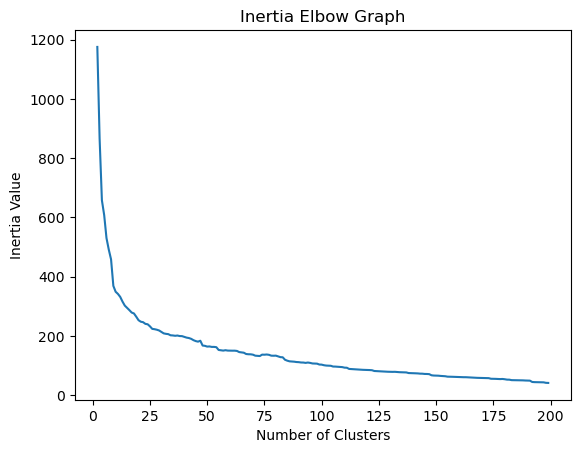

In [29]:
# Create the x and y parallel arrays.
x_data, y_data = create_x_and_y_parallel_array(my_data)

# Plot the Inertia line graph.
plot_line_graph(x_data, y_data, "Inertia Elbow Graph", "Number of Clusters", "Inertia Value")


From the above elbow graph, the ideal number of clusters is approximately 10 as that this is where the bend in the elbow is located.  

However, from a numerical perspective, it is based on the trade off between getting the lowest possible inertia value (i.e., how well the data is clustered) and having too many  clusters that the model looks over-fitted (i.e., where you have a large number of clusters that only contain 1 or 2 observations).

In the above graph, a model with 1 cluster has an inertia value approaching 1200.  Inertia is the sum of the distances between the data points in the cluster and the centroid.  Therefore, a large inertia value shows that the data is not well clustered.  On the opposite side, having 200 clusters will have a low inertia value.  That shows the data is well clustered in each cluster, however, there will only be one or two points per cluster which renders the model ineffective.

Let's use 10 clusters to create the Clustering model.

In [30]:
# Invoke the K-Means model with only 10 clusters.
my_kmeans = invoke_kmeans(X, 10)

# Print out some basic information about the data.
print_kmeans_data(my_kmeans)

Inertia:  348.8066974947993
n_iter:   20


The inertia value for 10 clusters is 348.  Once you have more than 10 clusters, the drop-off rate in the inertia value is quite small compared to a cluster value of 1-9.

In [31]:
my_kmeans.cluster_centers_

# 10 Clusters of 96 cluster_centres - each of the 96 points correspond from 12:00am-12:00am
# 24 hours of 15 minute samplings (4 / hour) = 4 * 24 = 96 values.
# 
# cluster_centers_ gives the Centroid mapping for each cluster for each of the 96 values. Taken
# altogether, it will give the central value over the course of the day.
# 


array([[0.96644201, 0.96434134, 0.96184034, 0.96794519, 0.96517923,
        0.96551467, 0.96048992, 0.95878964, 0.95915504, 0.96227334,
        0.9696839 , 0.97040725, 0.9672278 , 0.96428426, 0.95946141,
        0.95406703, 0.95148102, 0.94916962, 0.94248331, 0.93582078,
        0.93433056, 0.93265592, 0.93036556, 0.92413313, 0.92038401,
        0.9257084 , 0.92359986, 0.9201241 , 0.91694809, 0.9302696 ,
        0.93683027, 0.93573957, 0.93913121, 0.96871305, 0.99550271,
        1.01096079, 1.02068887, 1.02928726, 1.02533813, 1.0188139 ,
        1.02046972, 1.02180297, 1.02471251, 1.02977086, 1.03296556,
        1.03470382, 1.038372  , 1.03697172, 1.03256301, 1.02742751,
        1.02059347, 1.0221937 , 1.0182983 , 1.02599875, 1.04032814,
        1.04268328, 1.04009532, 1.04240089, 1.04292769, 1.04368801,
        1.04503863, 1.0438231 , 1.04488772, 1.04197583, 1.04298837,
        1.0436903 , 1.04104455, 1.04129728, 1.03973958, 1.03580612,
        1.04075799, 1.04610575, 1.05188635, 1.05

In [32]:
my_kmeans.labels_

# my_kmeans.labels_.size returns 349 which is the number of clients or number of weekly power 
# demands:
#
#     "The dataframe average_curves contains the 349 typical weekday electric demands"

array([0, 0, 0, 1, 1, 3, 1, 3, 3, 3, 3, 6, 2, 6, 6, 1, 3, 3, 3, 3, 3, 6,
       1, 3, 3, 1, 1, 1, 0, 1, 3, 0, 3, 1, 3, 2, 1, 6, 1, 3, 1, 3, 3, 1,
       4, 3, 3, 3, 3, 6, 3, 3, 1, 3, 3, 1, 3, 1, 0, 3, 1, 3, 1, 6, 1, 1,
       3, 1, 3, 3, 3, 3, 3, 1, 1, 3, 6, 3, 3, 1, 3, 3, 3, 6, 1, 3, 3, 3,
       3, 0, 0, 2, 8, 0, 2, 2, 2, 5, 5, 9, 5, 0, 5, 9, 9, 3, 6, 3, 2, 3,
       5, 6, 0, 4, 0, 7, 7, 7, 2, 2, 2, 4, 6, 6, 4, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 2, 0, 4, 0, 2, 6, 0, 1, 1, 0, 1, 0, 1, 4, 6, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 2, 4, 4, 4, 6, 6, 6, 6, 6, 6,
       6, 6, 4, 6, 6, 6, 4, 6, 6, 6, 6, 4, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
       6, 6, 4, 4, 4, 6, 6, 6, 6, 4, 6, 6, 4, 4, 4, 4, 4, 4, 4, 4, 6, 6,
       4, 4, 4, 4, 4, 6, 4, 4, 4, 4, 4, 6, 4, 4, 4, 4, 4, 4, 4, 6, 4, 4,
       6, 4, 4, 4, 4, 4, 4, 6, 4, 6, 6, 6, 6, 6, 4, 6, 4, 6, 6, 6, 6, 6,
       6, 6, 4, 6, 4, 6, 4, 6, 6, 4, 4, 4, 6, 4, 6, 6, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 6, 6, 6, 4, 4, 4, 6, 6, 4, 4, 4, 6,

In [33]:
my_kmeans.labels_.size

349

In [34]:
my_array = my_kmeans.cluster_centers_[0]

In [35]:
my_array

array([0.96644201, 0.96434134, 0.96184034, 0.96794519, 0.96517923,
       0.96551467, 0.96048992, 0.95878964, 0.95915504, 0.96227334,
       0.9696839 , 0.97040725, 0.9672278 , 0.96428426, 0.95946141,
       0.95406703, 0.95148102, 0.94916962, 0.94248331, 0.93582078,
       0.93433056, 0.93265592, 0.93036556, 0.92413313, 0.92038401,
       0.9257084 , 0.92359986, 0.9201241 , 0.91694809, 0.9302696 ,
       0.93683027, 0.93573957, 0.93913121, 0.96871305, 0.99550271,
       1.01096079, 1.02068887, 1.02928726, 1.02533813, 1.0188139 ,
       1.02046972, 1.02180297, 1.02471251, 1.02977086, 1.03296556,
       1.03470382, 1.038372  , 1.03697172, 1.03256301, 1.02742751,
       1.02059347, 1.0221937 , 1.0182983 , 1.02599875, 1.04032814,
       1.04268328, 1.04009532, 1.04240089, 1.04292769, 1.04368801,
       1.04503863, 1.0438231 , 1.04488772, 1.04197583, 1.04298837,
       1.0436903 , 1.04104455, 1.04129728, 1.03973958, 1.03580612,
       1.04075799, 1.04610575, 1.05188635, 1.05321155, 1.05223

In [36]:
# Make a copy of X to keep X intact.
my_X_copy = X.copy()

In [37]:
my_X_copy.shape

(349, 96)

In [38]:
cluster_labels = my_kmeans.labels_

cluster_dict = {}
cluster_index = 0

# Iterate over the cluster labels and build the cluster dictionary of associated arrays
# that will contain the individual records.  These records are stored in the master X.

for i in cluster_labels:

    # If the cluster label dictionary key has not been created yet, create it.
    if (i not in cluster_dict.keys()):
        cluster_array = []
    else:
        # Cluster label dictionary key has been created.  Therefore, get the array.
        cluster_array = cluster_dict.get(i)

    # Append the record to the cluster and set it back to the dictionary.
    cluster_array.append(my_X_copy[cluster_index])
    cluster_dict[i] = cluster_array
    
    # Increment the cluster index.
    cluster_index += 1

# Print the cluster dictionary keys to ensure that all the clusters were created.
print (cluster_dict.keys())


dict_keys([0, 1, 3, 6, 2, 4, 8, 5, 9, 7])


In [39]:
# Just as a test, print out the number of clients in a random cluster.
print (len(cluster_dict[4]))

96


In [40]:
# create_cluster_dataframe

def create_cluster_dataframe(cluster_array, transpose=True):

    # Create the base dataframe from the input array.
    df = pd.DataFrame(cluster_array)
    
    # Check if transposing is on.
    if transpose:
        # Transpose the DataFrame so that the x-axis is now the y-axis
        df_transposed = df.T  
    else:
        df_transposed = df

    # Add the timeseries and set it as the index.
    df_transposed['Hour'] =  pd.date_range('2013-01-01', periods=96, freq="15min")
    df_transposed = df_transposed.set_index('Hour')
    
    return df_transposed

In [41]:
# plot_dataframe

def plot_dataframe(df, title="No Title", x_axis="No X", y_axis="No Y"):

    # Calculate the number of records in the cluster.
    num_cluster_columns = df.shape[1] # - 1

    # Set the title, axis labels and font sizes.
    plt.title(title + " (Number of Clients: " + str(num_cluster_columns) + ")", fontsize=20)
    plt.xlabel(x_axis, fontsize=15)
    plt.ylabel(y_axis, fontsize=15)
    plt.xticks(rotation=30, fontsize=10)

    # Set the x-axis to only show the Hour-Minute data.
    xformatter = mdates.DateFormatter('%H:%M')
    plt.gcf().axes[0].xaxis.set_major_formatter(xformatter)
    
    # Set the index to be the Hour field.
   # for col in range (0, num_cluster_columns):
    
    for col in df.columns:
        plt.plot(df.index, df[col])
        
    plt.show()

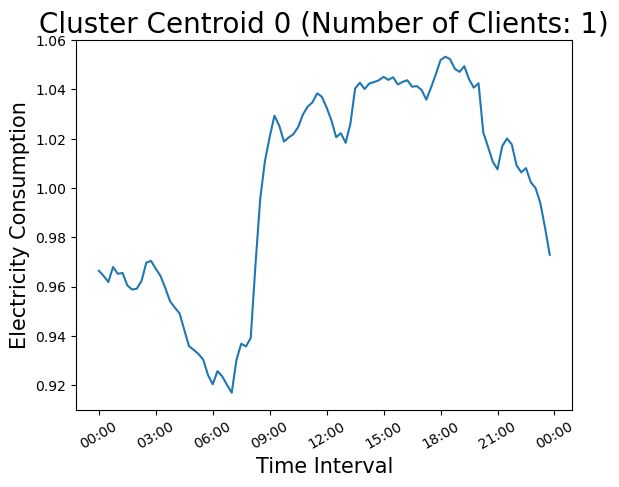

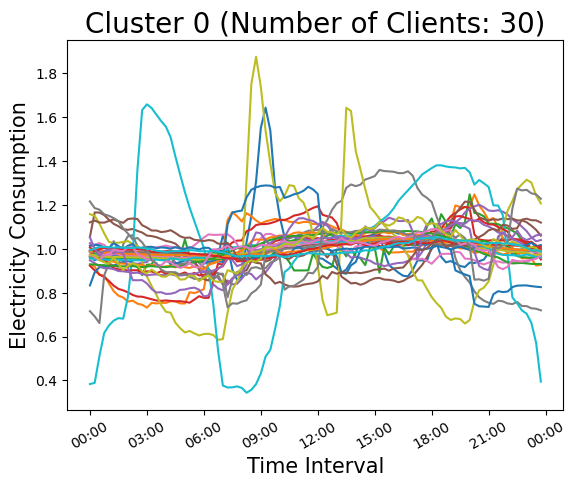

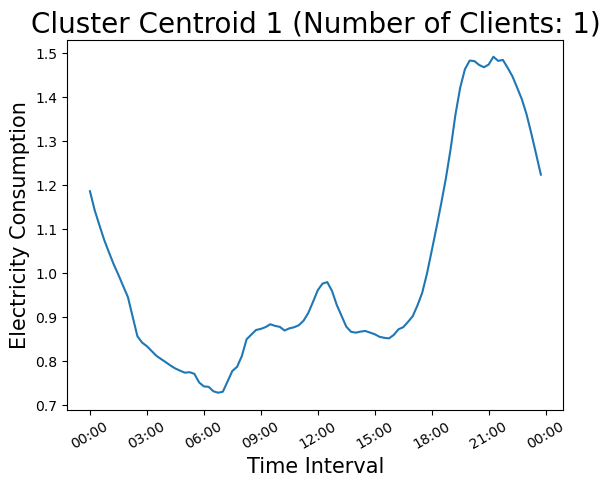

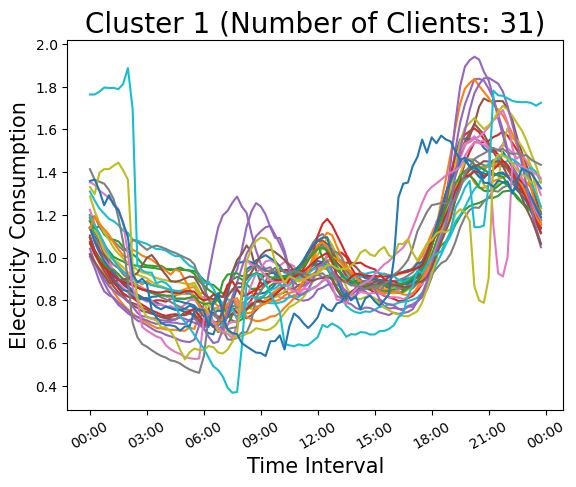

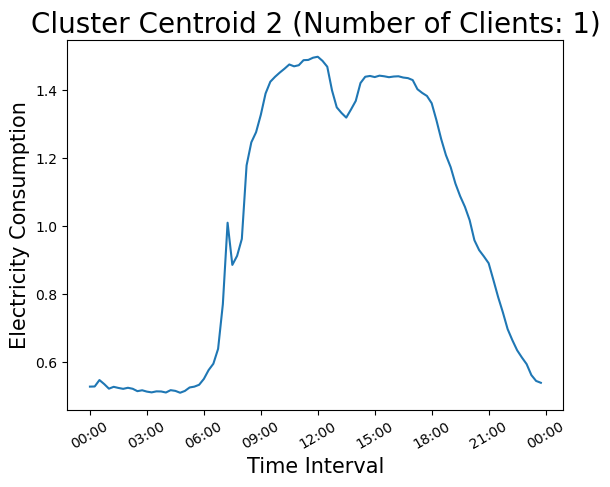

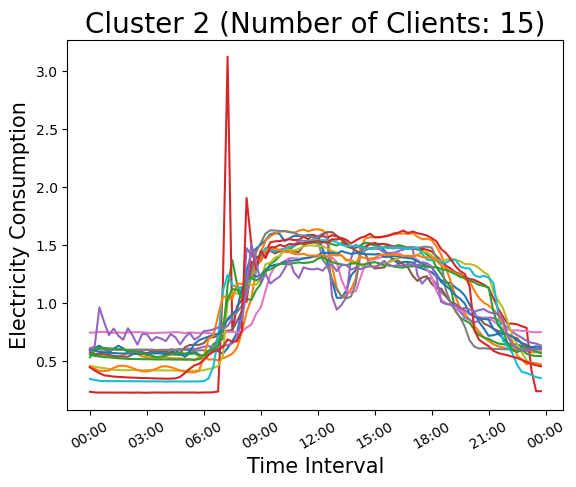

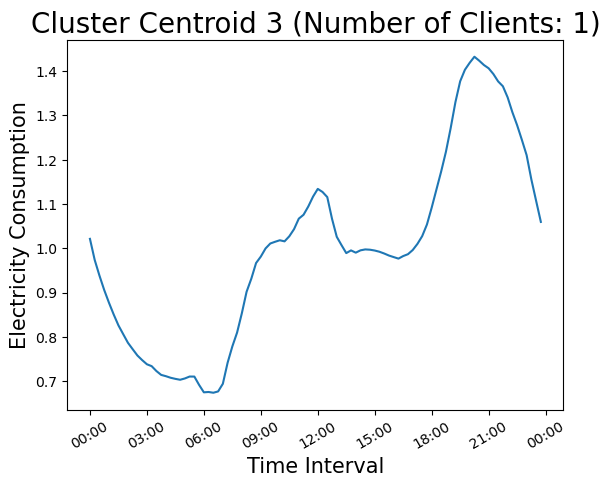

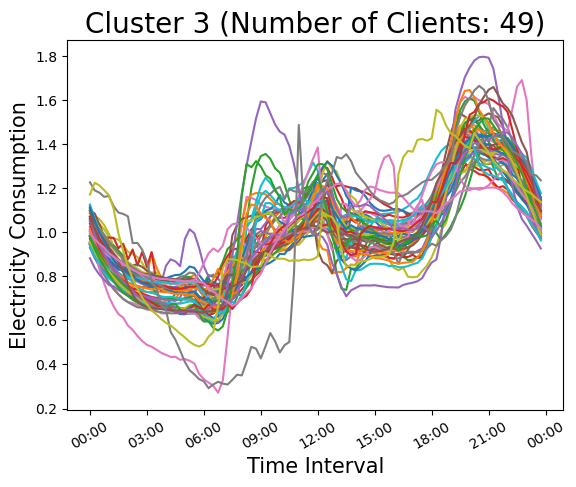

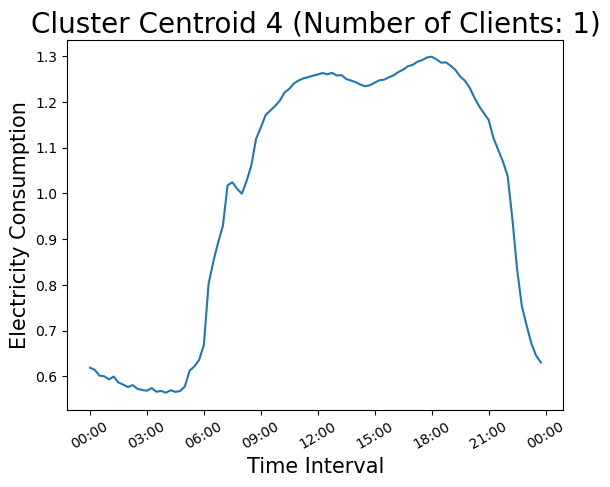

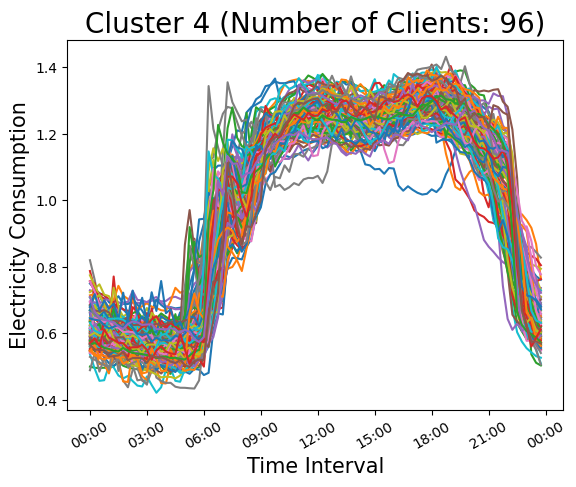

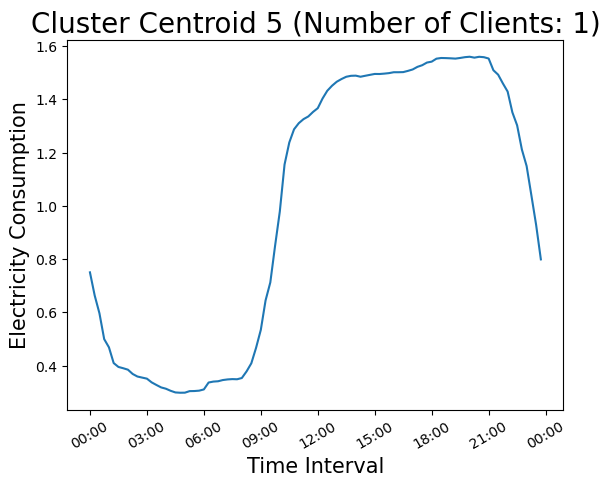

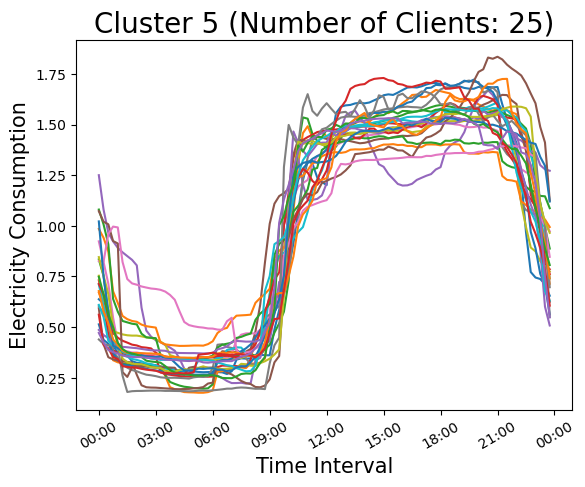

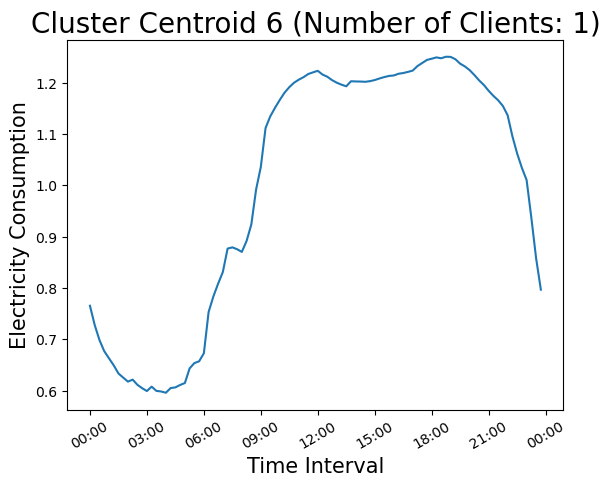

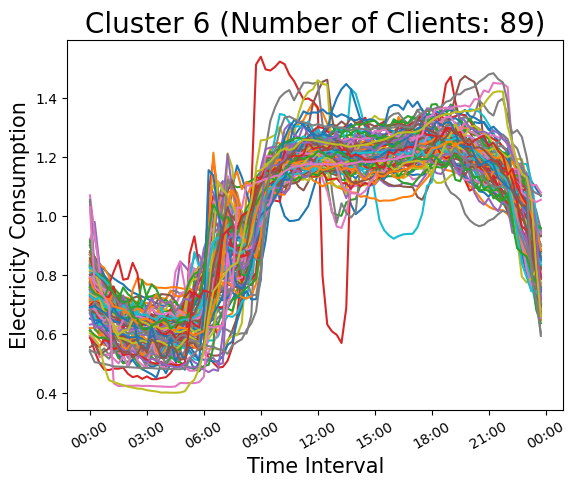

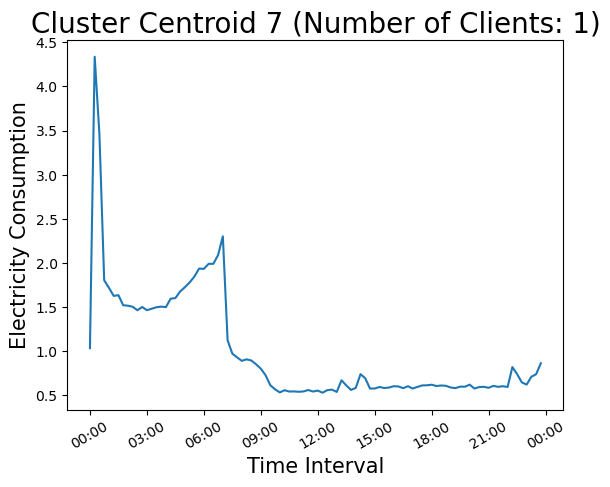

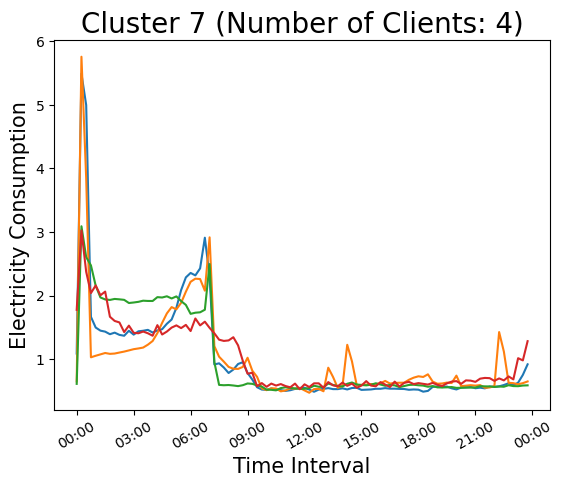

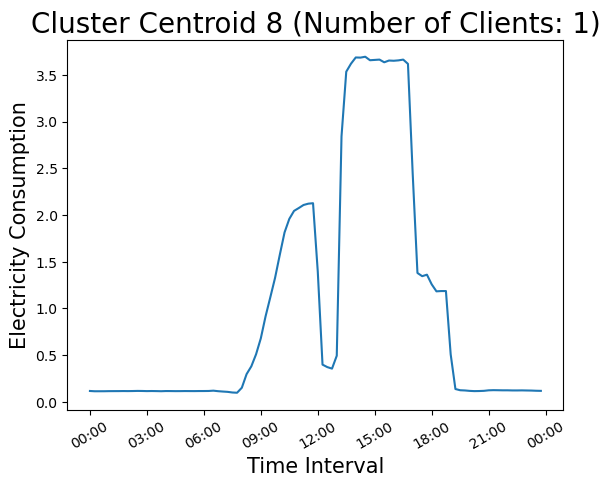

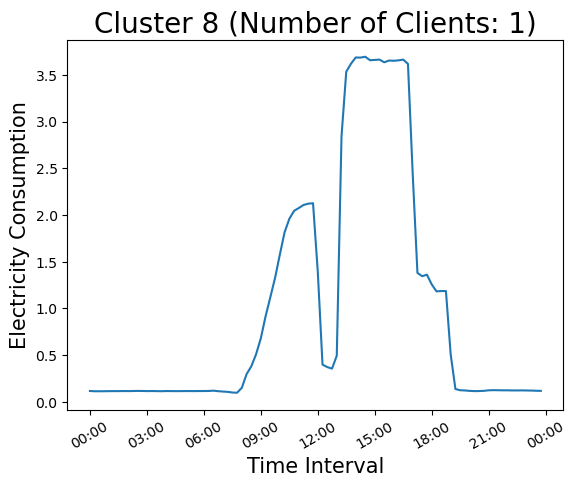

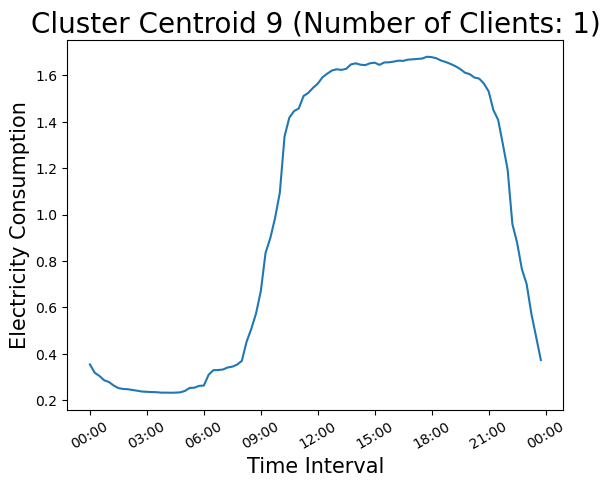

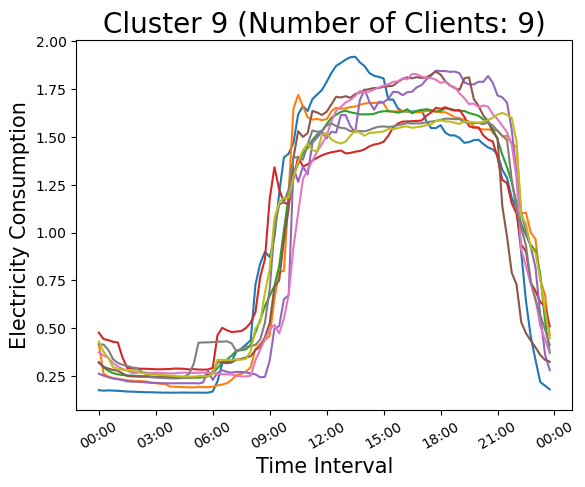

In [42]:
# Iterate over the clusters to create and display the Cluster Centroid and
# Cluster data.

for i in range (0, len(cluster_dict)):

    # Create and plot the cluster centroid.
    my_cc_df = create_cluster_dataframe(my_kmeans.cluster_centers_[i], False)
    plot_dataframe(my_cc_df, "Cluster Centroid " + str(i), "Time Interval", "Electricity Consumption")
        
    # Create and plot the cluster data.
    my_df = create_cluster_dataframe(cluster_dict[i])
    plot_dataframe(my_df, "Cluster " + str(i), "Time Interval", "Electricity Consumption")

As can be seen by the clusters, the data has been clustered around when the clients typically start increasing their electriciy consumption.  Some clusters increase their electricity consumption in the morning (e.g., 6:00am, 9:00am) until 9:00pm at night where it drops off.  Other clusters ebb and flow during the day while others increase at night.

**Q2: (8 marks)**

In this exercise you work with the daily curves of 1 single client.
First, create a list of arrays, each array containing a curve for a day. You may use X from the cells above.
    X = average_curves_norm.copy() 
The list contains 730 arrays, one for each of the days of 2013 and 2014.

a. Determine the optimal value of k ( number of clusters). This time you may also perform silhoutte analysis as stated in the module. Carrying out silhoutte analysis is left as an exercise. What do you understand about the clusters? 

b. Based on your results from your analyses of both methods, what do understand?  Interpret it perhaps with different perspectives of timelines like weeks or months.

In [43]:
client = 'MT_022'
oneClient = data_13_14[client]
X = [] # a list of arrays, each array being a normalized curve for a day
for J in range(2*365):
    X.extend([np.array(oneClient[J*96:(J+1)*96])])#/np.mean(oneClient[J*96:(J+1)*96])]) 

In [44]:
len(X)

730

In [45]:
# Print out Day 1.
print(X[0])

[31.13325031 28.64259029 27.39726027 24.90660025 24.28393524 26.15193026
 26.15193026 24.90660025 26.77459527 23.66127024 23.66127024 21.17061021
 23.03860523 19.30261519 18.67995019 18.67995019 19.30261519 19.30261519
 18.67995019 19.30261519 18.05728518 18.05728518 17.43462017 16.81195517
 17.43462017 17.43462017 17.43462017 17.43462017 18.67995019 21.17061021
 19.30261519 20.54794521 19.9252802  21.17061021 20.54794521 21.79327522
 24.90660025 31.13325031 23.66127024 19.30261519 21.79327522 20.54794521
 13.69863014 16.81195517 15.56662516 18.05728518 18.05728518 16.81195517
 19.9252802  16.81195517 18.05728518 20.54794521 16.81195517 18.67995019
 21.17061021 19.9252802  16.81195517 16.18929016 17.43462017 18.05728518
 18.67995019 15.56662516 18.05728518 19.30261519 18.05728518 15.56662516
 17.43462017 18.05728518 16.18929016 19.9252802  26.77459527 28.01992528
 29.26525529 33.00124533 33.62391034 34.86924035 36.73723537 34.86924035
 31.75591532 34.24657534 35.49190535 33.62391034 31

In [46]:
# Convert the array into a Dataframe and print it out to verify.
my_client_df = create_cluster_dataframe(X, transpose=True)
my_client_df.head()


,0,1,2,3,4,5,6,7,8,9,...,720,721,722,723,724,725,726,727,728,729
Hour,,,,,,,,,,,,,,,,,,,,,
2013-01-01 00:00:00,31.133250,22.415940,21.793275,23.661270,19.925280,27.397260,21.793275,23.038605,21.170610,21.793275,...,29.887920,26.774595,25.529265,25.529265,23.661270,21.170610,31.133250,28.642590,29.265255,24.906600
2013-01-01 00:15:00,28.642590,22.415940,21.170610,22.415940,19.302615,25.529265,21.793275,24.283935,22.415940,19.302615,...,28.019925,28.019925,24.906600,25.529265,23.038605,21.793275,29.265255,29.887920,29.887920,26.774595
2013-01-01 00:30:00,27.397260,20.547945,20.547945,22.415940,19.925280,24.283935,21.793275,21.170610,21.170610,19.302615,...,25.529265,25.529265,23.038605,26.151930,23.038605,21.170610,28.019925,27.397260,30.510585,23.661270
2013-01-01 00:45:00,24.906600,20.547945,19.925280,21.793275,19.302615,23.661270,21.170610,21.170610,19.302615,18.057285,...,24.283935,24.906600,24.283935,28.019925,23.038605,20.547945,28.019925,28.642590,28.642590,22.415940
2013-01-01 01:00:00,24.283935,22.415940,19.302615,22.415940,18.057285,23.038605,20.547945,19.302615,17.434620,16.811955,...,24.283935,24.283935,23.038605,25.529265,23.038605,21.793275,26.151930,26.774595,28.019925,22.415940


In [47]:
my_data = []

# Invoke kmeans clustering starting from 2 clusters to 200 clusters and calculate the 
# inertia (sum of total distances).

for i in range(2, 200):
    
    # Invoke kmeans and append the inertia to the array.
    my_kmeans = invoke_kmeans(X, i)
    my_data.append([i, my_kmeans.inertia_])

print (my_data[0], my_data[1])


[2, 2599946.1576933414] [3, 2126832.522495338]


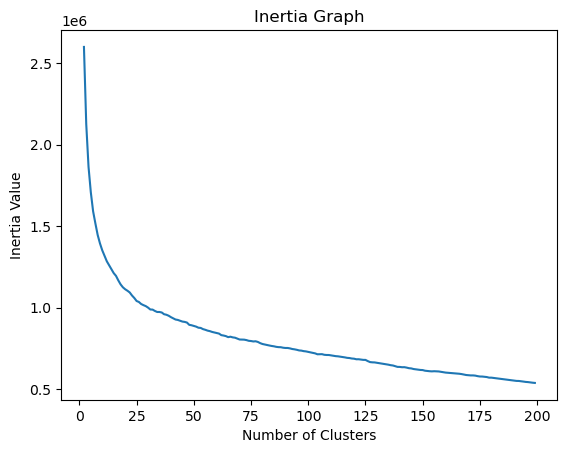

In [48]:
# Create the x and y parallel arrays.
x_data, y_data = create_x_and_y_parallel_array(my_data)

# Plot the graph.
plot_line_graph(x_data, y_data, "Inertia Graph", "Number of Clusters", "Inertia Value")


About 5 clusters appears to be near optimal using the Elbow method.  Let's look at the Silhouette scores for the top 10 clusters to see how well the clusters are separated.

In [49]:
# calculate_silhouette_score

def calculate_silhouette_score(X_in, num_clusters):
    
    # Invoke the KMeans model.
    kmeans_model = invoke_kmeans(X_in, num_clusters)
    labels = kmeans_model.labels_
    
    # Return the Silhouette score.
    return metrics.silhouette_score(X_in, labels, metric='euclidean')

In [50]:
s_data = []

# Iterate over 8 clusters to help determine optimal number of clusters.
for i in range (2, 10):
    
    # Calculate the Silhouette score and append it to the array.
    silhouette_score = calculate_silhouette_score(X, i)
    s_data.append([i, silhouette_score])

# Print out the scores for each cluster.
print ("Cluster\t\tSilhouette Score")
print ("-------\t\t----------------")

for i in s_data:
    print(i[0], "\t\t", i[1])


Cluster		Silhouette Score
-------		----------------
2 		 0.5011374240143707
3 		 0.282197741615619
4 		 0.2809290661743728
5 		 0.2196591577577872
6 		 0.1953811199831549
7 		 0.18947575577594933
8 		 0.18233667659817948
9 		 0.18300482042326768


In the Silouette Graph, we are looking for a value as close to 1 as possible.  As it is all downhill after 2 clusters, the ideal number of clusters is 2. 

In [51]:
# Calculate the Silhouette score for 2 clusters.
silhouette_score = calculate_silhouette_score(X, 2)
print ("Silhouette score for 2 clusters is ", silhouette_score)

Silhouette score for 2 clusters is  0.5011374240143707


The Silhouette score for 2 clusters is 0.50 which is not too bad.  It shows that these clusters are well separated.

Let's create these two clusters.

In [52]:
# Invoke the K-Means model with only 10 clusters.
my_kmeans = invoke_kmeans(X, 2)

# Print out some basic information about the data.
print_kmeans_data(my_kmeans)

Inertia:  2599946.1576933414
n_iter:   5


In [53]:
# Make a copy of X to keep X intact.
my_X_copy = X.copy()

In [54]:
cluster_labels = my_kmeans.labels_

cluster_dict = {}
cluster_index = 0

# Iterate over the cluster labels and build the cluster dictionary of associated arrays
# that will contain the individual records.  These records are stored in the master X.

for i in cluster_labels:

    # If the cluster label dictionary key has not been created yet, create it.
    if (i not in cluster_dict.keys()):
        cluster_array = []
    else:
        # Cluster label dictionary key has been created.  Therefore, get the array.
        cluster_array = cluster_dict.get(i)

    # Append the record to the cluster and set it back to the dictionary.
    cluster_array.append(my_X_copy[cluster_index])
    cluster_dict[i] = cluster_array
    
    # Increment the cluster index.
    cluster_index += 1

# Print the cluster dictionary keys to ensure that all the clusters were created.
print (cluster_dict.keys())


dict_keys([1, 0])


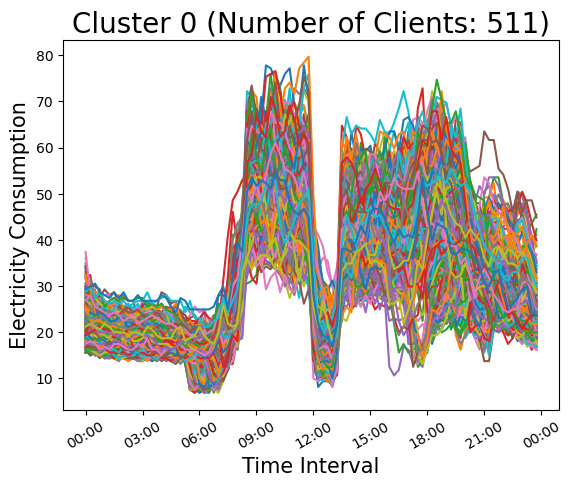

In [55]:
# Create the first cluster ("0") and plot the graph (Note "Clients" is actually "Observations").
one_client_cluster0 = create_cluster_dataframe(cluster_dict[0])
plot_dataframe(one_client_cluster0, "Cluster 0", "Time Interval", "Electricity Consumption")


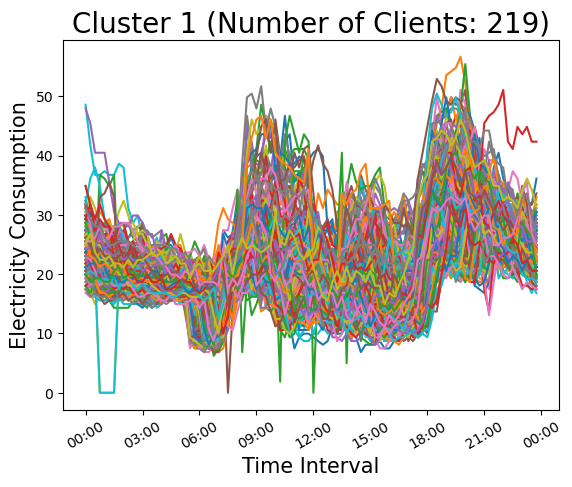

In [56]:
# Create the second cluster ("1") and plot the graph (Note "Clients" is actually "Observations").
one_client_cluster1 = create_cluster_dataframe(cluster_dict[1])
plot_dataframe(one_client_cluster1, "Cluster 1", "Time Interval", "Electricity Consumption")


With only two clusters, it may be the case of having too many observations in one cluster.  However, generally speaking, there are two distinct types of electricity usage.  In the first cluster, Cluster 0, there is generally low demand until 6:00am when usage increases and stays constant until midday when they leave for lunch.  Demand increases again at 1:00pm and stays constant until it slowly drops off around 9:00pm.  Given the number of observations (511), this must be the regular work week.  Maybe they work from home.

In the second cluster, demand is similarly low until 6:00am and then it jumps up around 9:00am.  It slightly declines over the day until 6:00pm.  It increases again in the evening before declining after 9:00pm.  Given the number of observations (219), this must be the weekends.

Let's plot the total number of observations and then by day of week.

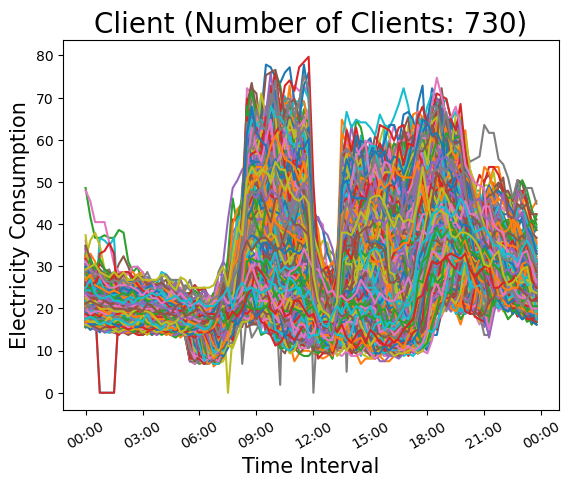

In [57]:
plot_dataframe(my_client_df, "Client", "Time Interval", "Electricity Consumption")


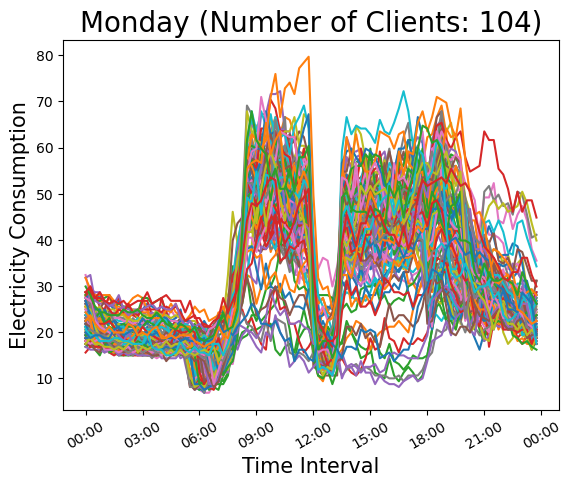

In [58]:
mon_df = my_client_df[my_client_df.columns[6::7]]
plot_dataframe(mon_df, "Monday", "Time Interval", "Electricity Consumption")


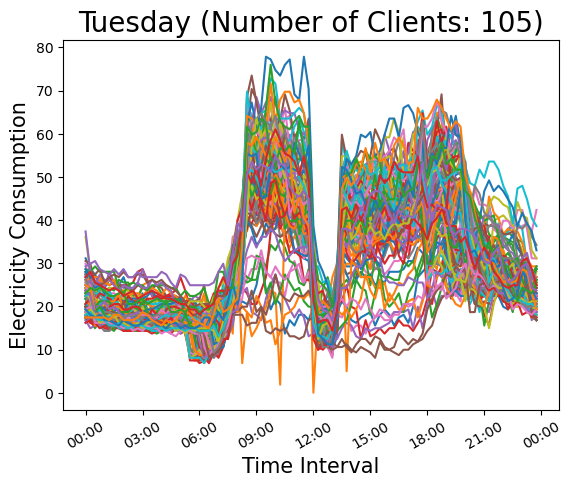

In [59]:
tue_df = my_client_df[my_client_df.columns[::7]]
plot_dataframe(tue_df, "Tuesday", "Time Interval", "Electricity Consumption")


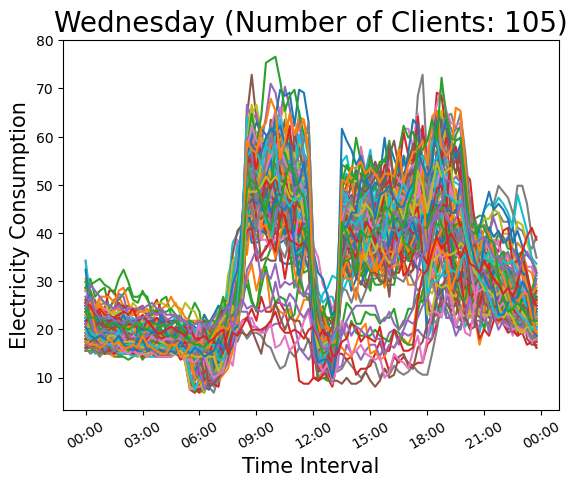

In [60]:
wed_df = my_client_df[my_client_df.columns[1::7]]
plot_dataframe(wed_df, "Wednesday", "Time Interval", "Electricity Consumption")


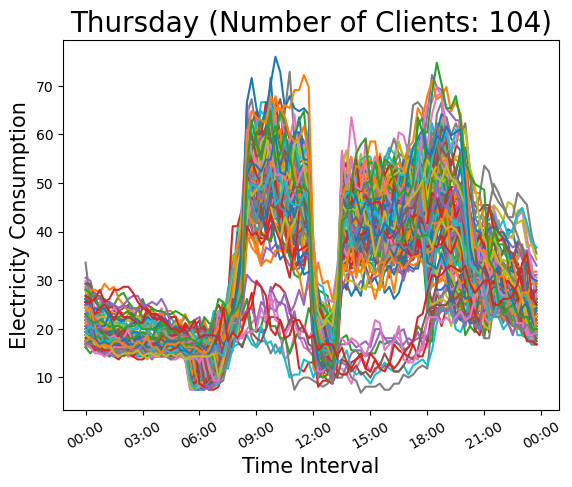

In [61]:
thur_df = my_client_df[my_client_df.columns[2::7]]
plot_dataframe(thur_df, "Thursday", "Time Interval", "Electricity Consumption")

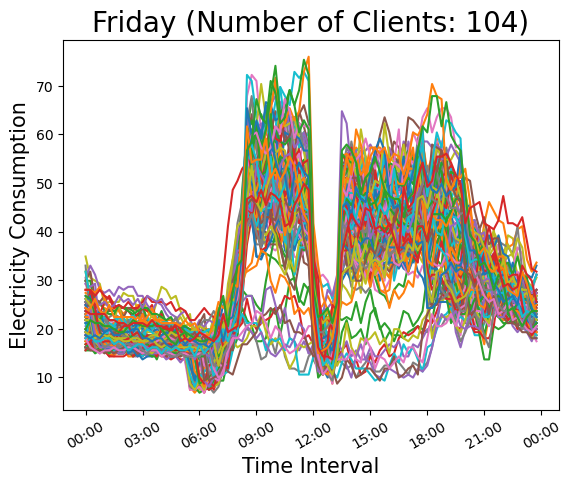

In [62]:
fri_df = my_client_df[my_client_df.columns[3::7]]
plot_dataframe(fri_df, "Friday", "Time Interval", "Electricity Consumption")


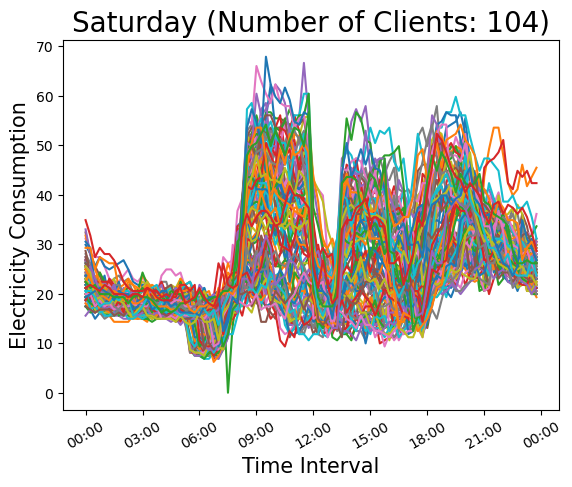

In [63]:
sat_df = my_client_df[my_client_df.columns[4::7]]
plot_dataframe(sat_df, "Saturday", "Time Interval", "Electricity Consumption")


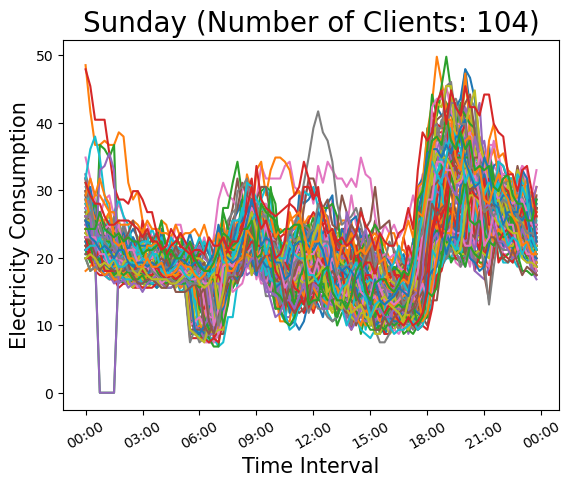

In [64]:
sun_df = my_client_df[my_client_df.columns[5::7]]
plot_dataframe(sun_df, "Sunday", "Time Interval", "Electricity Consumption")

From the above graphs, the days, Monday - Saturday, look like they fit in the first Cluster ("0") while Sunday looks like it would fit in the second Cluster ("1").

#### The following cell generates a list of all the days in the two years 2013-2014, which is helpful to answer part (b).  The cells below are only to give you a headstart.  You may or may not use these and come up with your own interpretation.


In [65]:
from datetime import date, timedelta

d1 = date(2013, 1, 1)  # start date
d2 = date(2014, 12, 31)  # end date
delta = d2 - d1         # timedelta
daysyear = []
D = {0:'mon', 1:'tue', 2:'wed', 3:'thu', 4:'fri', 5:'sat', 6:'sun'}
for i in range(delta.days + 1):
    daysyear.extend([D[(d1 + timedelta(days=i)).weekday()]+"-"+str(d1 + timedelta(days=i))])
    
print (len(daysyear))

730


In [66]:
print (daysyear)

['tue-2013-01-01', 'wed-2013-01-02', 'thu-2013-01-03', 'fri-2013-01-04', 'sat-2013-01-05', 'sun-2013-01-06', 'mon-2013-01-07', 'tue-2013-01-08', 'wed-2013-01-09', 'thu-2013-01-10', 'fri-2013-01-11', 'sat-2013-01-12', 'sun-2013-01-13', 'mon-2013-01-14', 'tue-2013-01-15', 'wed-2013-01-16', 'thu-2013-01-17', 'fri-2013-01-18', 'sat-2013-01-19', 'sun-2013-01-20', 'mon-2013-01-21', 'tue-2013-01-22', 'wed-2013-01-23', 'thu-2013-01-24', 'fri-2013-01-25', 'sat-2013-01-26', 'sun-2013-01-27', 'mon-2013-01-28', 'tue-2013-01-29', 'wed-2013-01-30', 'thu-2013-01-31', 'fri-2013-02-01', 'sat-2013-02-02', 'sun-2013-02-03', 'mon-2013-02-04', 'tue-2013-02-05', 'wed-2013-02-06', 'thu-2013-02-07', 'fri-2013-02-08', 'sat-2013-02-09', 'sun-2013-02-10', 'mon-2013-02-11', 'tue-2013-02-12', 'wed-2013-02-13', 'thu-2013-02-14', 'fri-2013-02-15', 'sat-2013-02-16', 'sun-2013-02-17', 'mon-2013-02-18', 'tue-2013-02-19', 'wed-2013-02-20', 'thu-2013-02-21', 'fri-2013-02-22', 'sat-2013-02-23', 'sun-2013-02-24', 'mon-2013

#### The following cell shows you how to do the following: given a list L, and a list of booleans B (True, False), get the sublist of L that corresponds to the True values in B. For example if L=[1,2,3,4] and B=[False,True,True,False], then the results is [2,3]. This is also helpful for pard (b)

In [67]:
from itertools import compress
L = [1,2,3,4]
B = [False, True, True, False]
list(compress(L, B))

[2, 3]

Continue with your analysis here: